<a href="https://colab.research.google.com/github/sarabhosale216/PRODIGY_DS_04/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_csv("/content/twitter_training.csv",
                 header=None,
                 names=["ID","Entity","Sentiment","Tweet"])
df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [3]:
df.isnull().sum()

,0
ID,0
Entity,0
Sentiment,0
Tweet,686


In [4]:
df.dropna(inplace=True)

In [5]:
df["Sentiment"].value_counts()

,count
Sentiment,
Negative,22358
Positive,20655
Neutral,18108
Irrelevant,12875


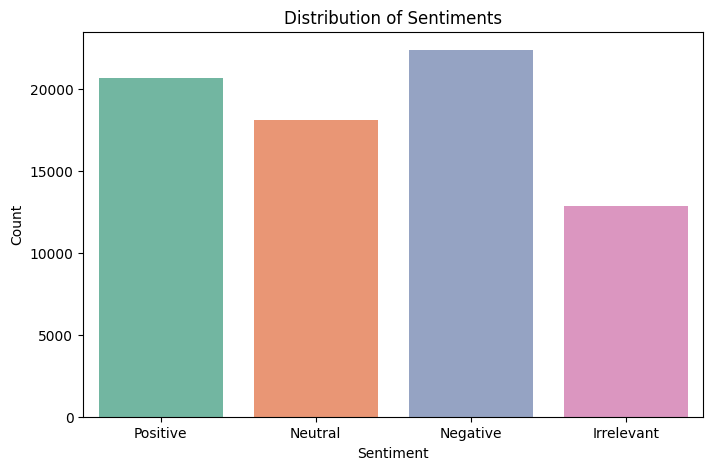

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Sentiment",
    data=df,
    palette="Set2",
    hue="Sentiment",
    legend=False
)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

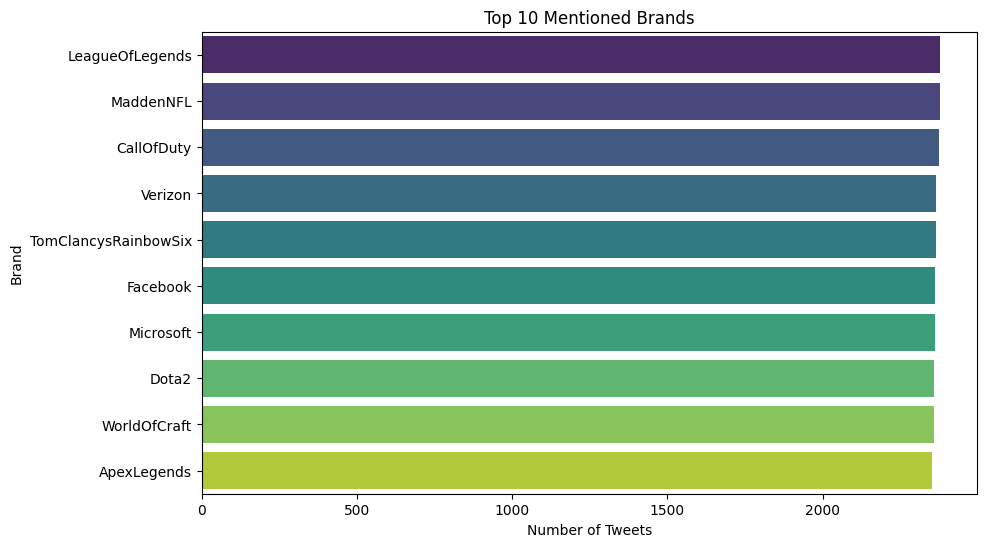

In [7]:
top_entities = df["Entity"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_entities.values,
    y=top_entities.index,
    palette="viridis",
    hue=top_entities.index,
    legend=False
)

plt.title("Top 10 Mentioned Brands")
plt.xlabel("Number of Tweets")
plt.ylabel("Brand")
plt.show()

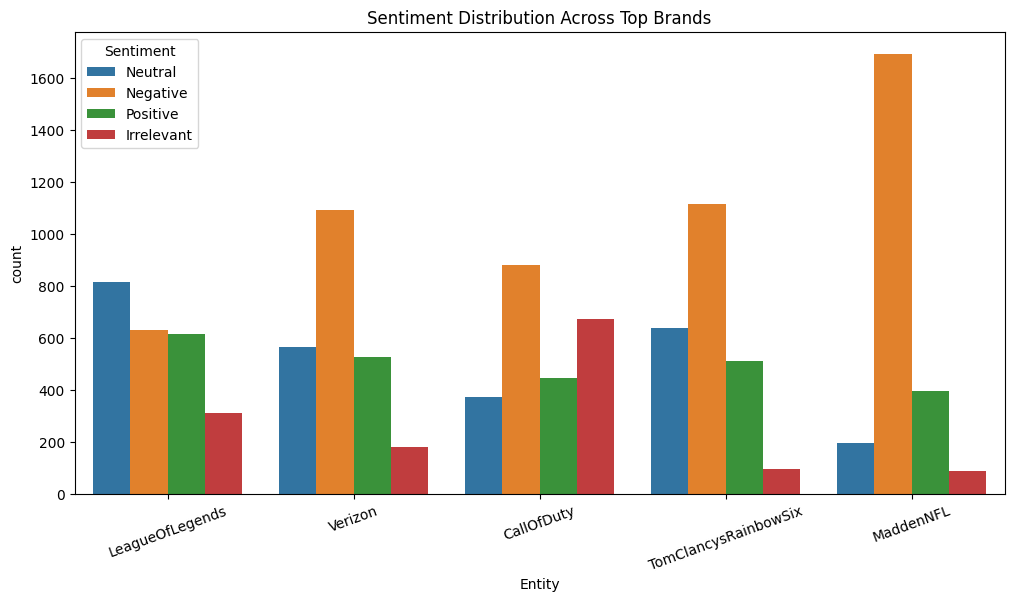

In [8]:
top5 = df["Entity"].value_counts().head(5).index

brand_df = df[df["Entity"].isin(top5)]

plt.figure(figsize=(12,6))

sns.countplot(
    data=brand_df,
    x="Entity",
    hue="Sentiment"
)

plt.title("Sentiment Distribution Across Top Brands")
plt.xticks(rotation=20)
plt.show()

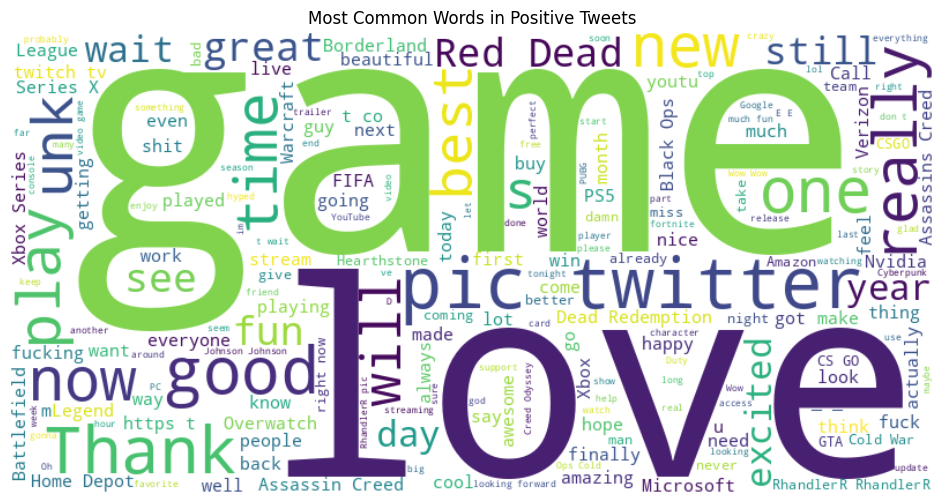

In [9]:
positive_text = " ".join(df[df["Sentiment"]=="Positive"]["Tweet"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Positive Tweets")
plt.show()

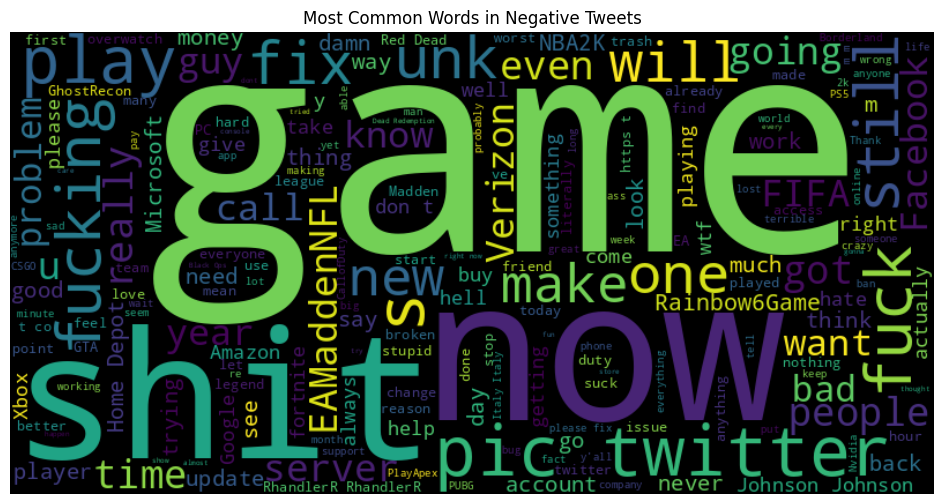

In [12]:
negative_text = " ".join(df[df["Sentiment"]=="Negative"]["Tweet"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="black"
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Negative Tweets")
plt.show()

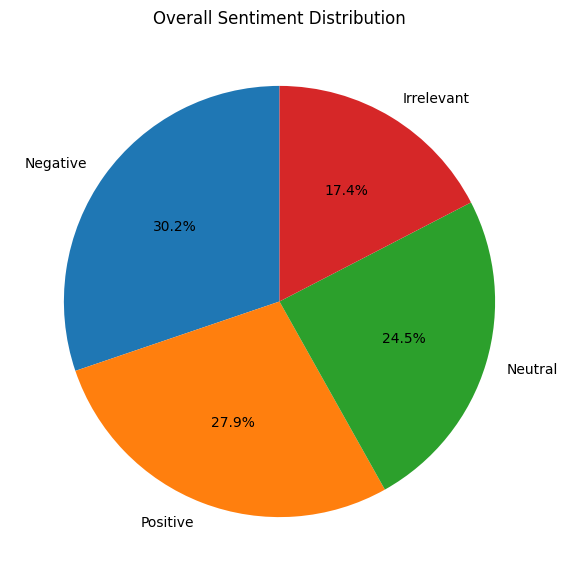

In [11]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Sentiment Distribution")
plt.show()